# runner-test Plots

Plot fidelity and latency for the `runner-test` log folders.


In [29]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


In [30]:
line_re = re.compile(
    r"run_id=(?P<run_id>\d+), time to serve=(?P<latency>[-+0-9.eE]+), "
    r"(?:fidelity_raw=(?P<fidelity_raw>[-+0-9.eE]+), fidelity_corrected=(?P<fidelity_corrected>[-+0-9.eE]+), )?"
    r"fidelity=(?P<fidelity>[-+0-9.eE]+)"
)

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"meas=(?P<meas>[0-9.]+|cfg),"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"(?:physbell=(?P<physbell>[0-9.]+|cfg),)?"
    r"ts=(?P<ts>\d{8}_\d{6}|\d{8}_\d{4})"
)

def load_runner_logs(log_dir: Path) -> pd.DataFrame:
    """Load one runner log directory into a flat dataframe.

    Args:
        log_dir: Directory containing runner log files.

    Returns:
        pd.DataFrame: One row per completed run.
    """
    rows = []
    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue

        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()
        log_mtime = path.stat().st_mtime
        nodes = int(meta["nodes"])
        num_links = nodes - 1
        elementary_link_km = float(meta["dist"])
        total_distance_km = num_links * elementary_link_km
        t2_value = float(meta["t2"])

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = line_re.search(line)
                if line_match is None:
                    continue

                rows.append({
                    "log_name": path.name,
                    "log_mtime": log_mtime,
                    "timestamp": meta["ts"],
                    "nodes": nodes,
                    "num_links": num_links,
                    "elementary_link_km": elementary_link_km,
                    "total_distance_km": total_distance_km,
                    "css_code": meta["code"],
                    "two_qubit_gate_fidelity": float(meta["twoq"]),
                    "gate_fidelity": float(meta["gate"]),
                    "measurement_fidelity": None if meta["meas"] == "cfg" else float(meta["meas"]),
                    "initialization_fidelity": float(meta["prep"]),
                    "physical_bell_pair_fidelity": None if meta.get("physbell") in (None, "cfg") else float(meta["physbell"]),
                    "data_t2": t2_value,
                    "comm_t2": t2_value,
                    "t1": float(meta["t1"]),
                    "correction_mode": meta["ccorr"],
                    "ft_prep_mode": meta["ft"],
                    "run_id": int(line_match["run_id"]),
                    "latency_ms": float(line_match["latency"]),
                    "fidelity": float(line_match["fidelity"]),
                    "fidelity_raw": float(line_match["fidelity_raw"]) if line_match["fidelity_raw"] is not None else float(line_match["fidelity"]),
                    "fidelity_corrected": float(line_match["fidelity_corrected"]) if line_match["fidelity_corrected"] is not None else float(line_match["fidelity"]),
                })

    return pd.DataFrame(rows)


In [31]:
project_dir = Path("/Users/patange/Documents/Argonne/QEC")
runner_test_root = project_dir / "log" / "runner-test"
output_dir = project_dir / "plot_pngs"
output_dir.mkdir(parents=True, exist_ok=True)

print(sorted(p.name for p in runner_test_root.iterdir() if p.is_dir()))


['graph_distance_sweep_2q_gate_0.997', 'graph_distance_sweep_physical_bellpair_0.99', 'graph_physical_bell_pair_fidelity_sweep', 'graph_two_qubit_gate_sweep']


In [32]:
colors = {"cec": "red", "none": "blue"}
names = {"cec": "QRE-CEC", "none": "QRE-None"}
markers = {"cec": "s", "none": "^"}


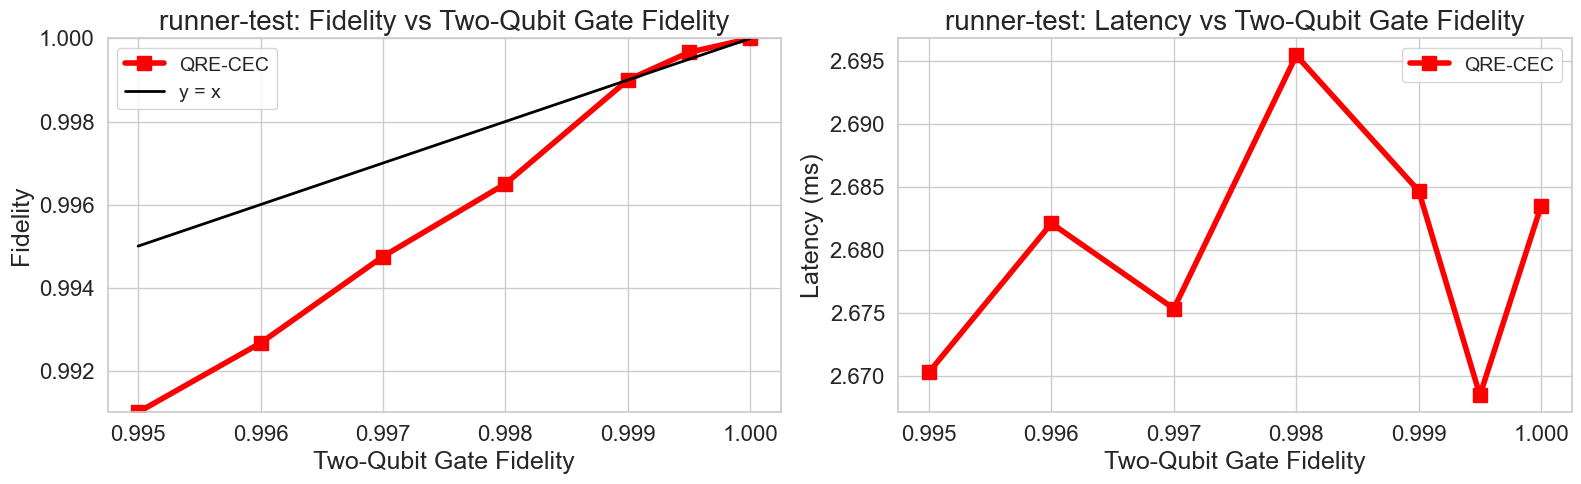

,two_qubit_gate_fidelity,correction_mode,mean_fidelity_corrected,mean_latency_ms
0,0.9950,cec,0.991000,2.670310
1,0.9960,cec,0.992667,2.682127
2,0.9970,cec,0.994750,2.675356
3,0.9980,cec,0.996500,2.695453
4,0.9990,cec,0.999000,2.684703
5,0.9995,cec,0.999667,2.668480
6,1.0000,cec,1.000000,2.683517


In [33]:
log_dir = runner_test_root / "graph_two_qubit_gate_sweep"
df = load_runner_logs(log_dir)

summary = (
    df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False)
    .agg(
        mean_fidelity_corrected=("fidelity_corrected", "mean"),
        mean_latency_ms=("latency_ms", "mean"),
    )
    .sort_values(["two_qubit_gate_fidelity", "correction_mode"])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax0 = axes[0]
ax1 = axes[1]

for protocol in ["cec", "none"]:
    data = summary[summary["correction_mode"] == protocol]
    if data.empty:
        continue

    ax0.plot(
        data["two_qubit_gate_fidelity"],
        data["mean_fidelity_corrected"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )
    ax1.plot(
        data["two_qubit_gate_fidelity"],
        data["mean_latency_ms"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )

identity_x = sorted(summary["two_qubit_gate_fidelity"].unique())
ax0.plot(identity_x, identity_x, color="black", linewidth=2, linestyle="-", label="y = x")

fidelity_min = float(summary["mean_fidelity_corrected"].min())
ax0.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
ax0.set_ylabel("Fidelity", fontsize=18)
ax0.set_title("runner-test: Fidelity vs Two-Qubit Gate Fidelity", fontsize=20)
ax0.set_ylim(fidelity_min, 1.0)
ax0.tick_params(axis="both", labelsize=16)
ax0.legend(fontsize=14)

ax1.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
ax1.set_ylabel("Latency (ms)", fontsize=18)
ax1.set_title("runner-test: Latency vs Two-Qubit Gate Fidelity", fontsize=20)
ax1.tick_params(axis="both", labelsize=16)
ax1.legend(fontsize=14)

plt.tight_layout()
plt.savefig(output_dir / "runner_test_graph_two_qubit_gate_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

summary


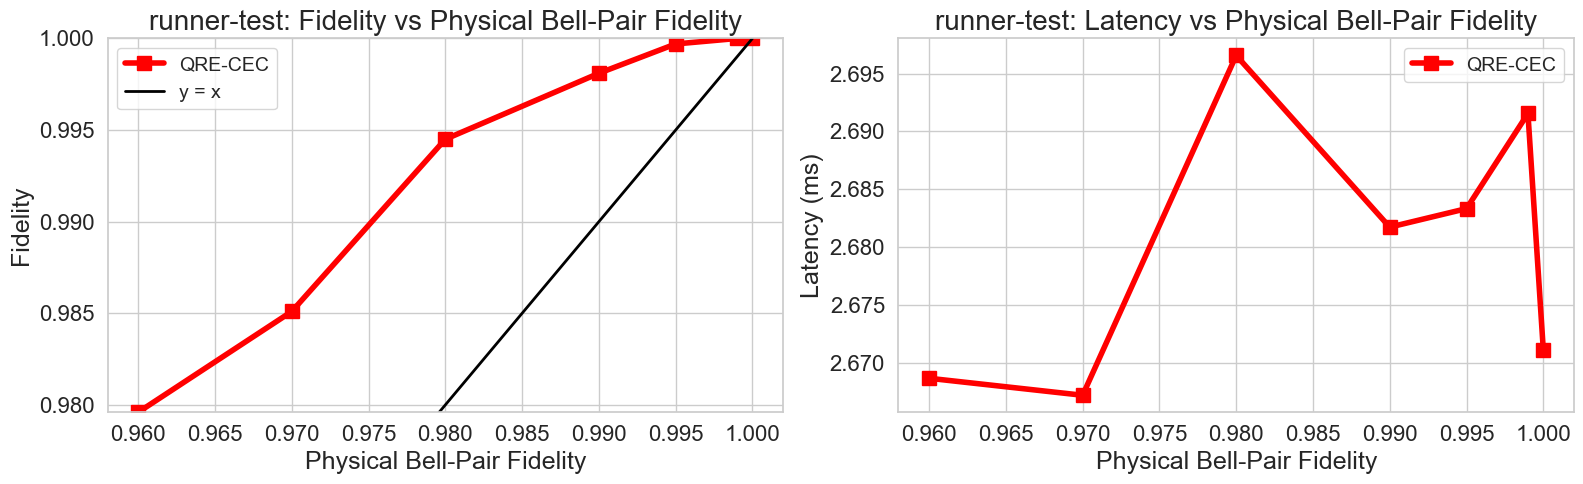

,physical_bell_pair_fidelity,correction_mode,mean_fidelity_corrected,mean_latency_ms
0,0.960,cec,0.9796,2.668646
1,0.970,cec,0.9851,2.667177
2,0.980,cec,0.9945,2.696572
3,0.990,cec,0.9981,2.681720
4,0.995,cec,0.9997,2.683322
5,0.999,cec,1.0000,2.691555
6,1.000,cec,1.0000,2.671121


In [34]:
log_dir = runner_test_root / "graph_physical_bell_pair_fidelity_sweep"
df = load_runner_logs(log_dir)

summary = (
    df.groupby(["physical_bell_pair_fidelity", "correction_mode"], as_index=False)
    .agg(mean_fidelity_corrected=("fidelity_corrected", "mean"),
        mean_latency_ms=("latency_ms", "mean"),).sort_values(["physical_bell_pair_fidelity", "correction_mode"]).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax0 = axes[0]
ax1 = axes[1]

for protocol in ["cec", "none"]:
    data = summary[summary["correction_mode"] == protocol]
    if data.empty:
        continue

    ax0.plot(
        data["physical_bell_pair_fidelity"],
        data["mean_fidelity_corrected"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )
    ax1.plot(
        data["physical_bell_pair_fidelity"],
        data["mean_latency_ms"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )

identity_x = sorted(summary["physical_bell_pair_fidelity"].unique())
ax0.plot(identity_x, identity_x, color="black", linewidth=2, linestyle="-", label="y = x")

fidelity_min = float(summary["mean_fidelity_corrected"].min())
ax0.set_xlabel("Physical Bell-Pair Fidelity", fontsize=18)
ax0.set_ylabel("Fidelity", fontsize=18)
ax0.set_title("runner-test: Fidelity vs Physical Bell-Pair Fidelity", fontsize=20)
ax0.set_ylim(fidelity_min, 1.0)
ax0.tick_params(axis="both", labelsize=16)
ax0.legend(fontsize=14)

ax1.set_xlabel("Physical Bell-Pair Fidelity", fontsize=18)
ax1.set_ylabel("Latency (ms)", fontsize=18)
ax1.set_title("runner-test: Latency vs Physical Bell-Pair Fidelity", fontsize=20)
ax1.tick_params(axis="both", labelsize=16)
ax1.legend(fontsize=14)

plt.tight_layout()
plt.savefig(output_dir / "runner_test_graph_physical_bell_pair_fidelity_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

summary


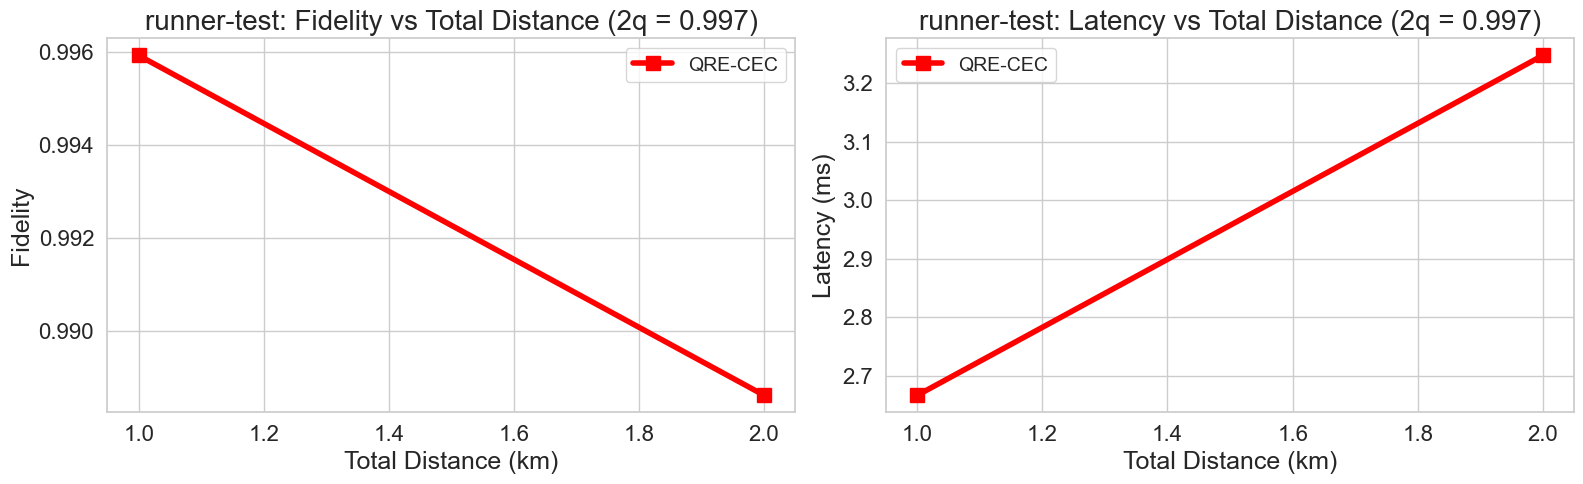

,total_distance_km,correction_mode,mean_fidelity_corrected,mean_latency_ms
0,1.0,cec,0.995917,2.66696
1,2.0,cec,0.988631,3.24785


In [35]:
log_dir = runner_test_root / "graph_distance_sweep_2q_gate_0.997"
df = load_runner_logs(log_dir)

summary = (
    df.groupby(["total_distance_km", "correction_mode"], as_index=False)
    .agg(
        mean_fidelity_corrected=("fidelity_corrected", "mean"),
        mean_latency_ms=("latency_ms", "mean"),
    )
    .sort_values(["total_distance_km", "correction_mode"])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax0 = axes[0]
ax1 = axes[1]

for protocol in ["cec", "none"]:
    data = summary[summary["correction_mode"] == protocol]
    if data.empty:
        continue

    ax0.plot(
        data["total_distance_km"],
        data["mean_fidelity_corrected"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )
    ax1.plot(
        data["total_distance_km"],
        data["mean_latency_ms"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )

ax0.set_xlabel("Total Distance (km)", fontsize=18)
ax0.set_ylabel("Fidelity", fontsize=18)
ax0.set_title("runner-test: Fidelity vs Total Distance (2q = 0.997)", fontsize=20)
ax0.tick_params(axis="both", labelsize=16)
ax0.legend(fontsize=14)

ax1.set_xlabel("Total Distance (km)", fontsize=18)
ax1.set_ylabel("Latency (ms)", fontsize=18)
ax1.set_title("runner-test: Latency vs Total Distance (2q = 0.997)", fontsize=20)
ax1.tick_params(axis="both", labelsize=16)
ax1.legend(fontsize=14)

plt.tight_layout()
plt.savefig(output_dir / "runner_test_graph_distance_sweep_2q_gate_0_997.png", dpi=300, bbox_inches="tight")
plt.show()

summary


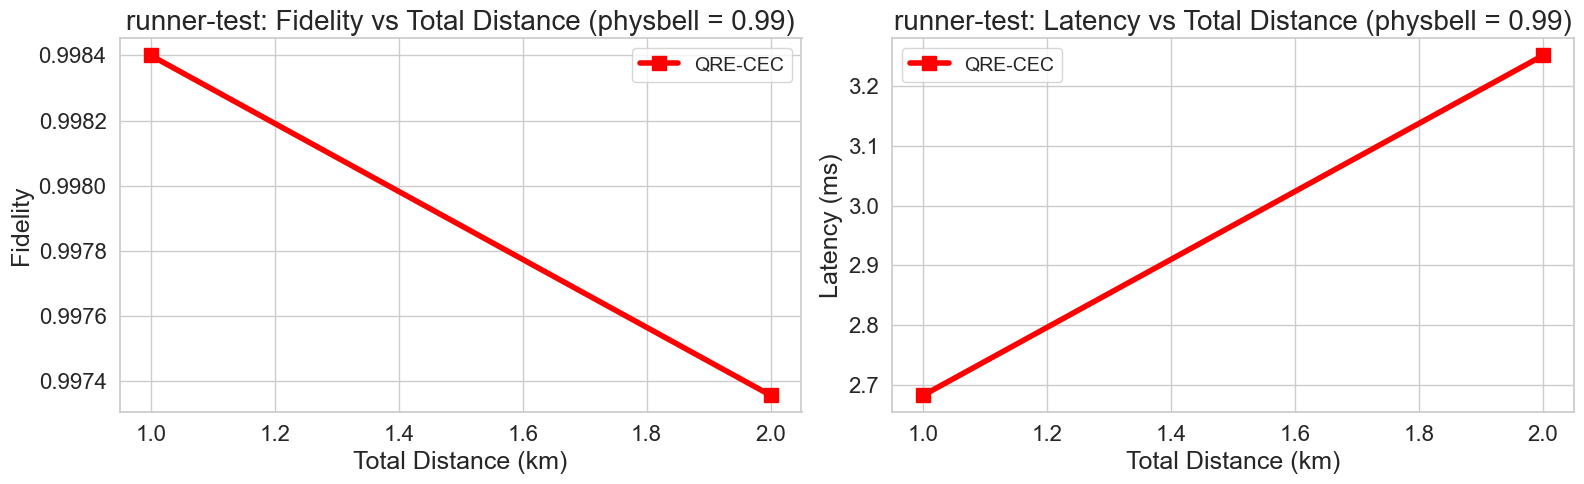

,total_distance_km,correction_mode,mean_fidelity_corrected,mean_latency_ms
0,1.0,cec,0.998400,2.683469
1,2.0,cec,0.997356,3.250496


In [36]:
log_dir = runner_test_root / "graph_distance_sweep_physical_bellpair_0.99"
df = load_runner_logs(log_dir)

summary = (
    df.groupby(["total_distance_km", "correction_mode"], as_index=False)
    .agg(
        mean_fidelity_corrected=("fidelity_corrected", "mean"),
        mean_latency_ms=("latency_ms", "mean"),
    )
    .sort_values(["total_distance_km", "correction_mode"])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax0 = axes[0]
ax1 = axes[1]

for protocol in ["cec", "none"]:
    data = summary[summary["correction_mode"] == protocol]
    if data.empty:
        continue

    ax0.plot(
        data["total_distance_km"],
        data["mean_fidelity_corrected"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )
    ax1.plot(
        data["total_distance_km"],
        data["mean_latency_ms"],
        color=colors[protocol],
        marker=markers[protocol],
        linewidth=4,
        markersize=10,
        label=names[protocol],
    )

ax0.set_xlabel("Total Distance (km)", fontsize=18)
ax0.set_ylabel("Fidelity", fontsize=18)
ax0.set_title("runner-test: Fidelity vs Total Distance (physbell = 0.99)", fontsize=20)
ax0.tick_params(axis="both", labelsize=16)
ax0.legend(fontsize=14)

ax1.set_xlabel("Total Distance (km)", fontsize=18)
ax1.set_ylabel("Latency (ms)", fontsize=18)
ax1.set_title("runner-test: Latency vs Total Distance (physbell = 0.99)", fontsize=20)
ax1.tick_params(axis="both", labelsize=16)
ax1.legend(fontsize=14)

plt.tight_layout()
plt.savefig(output_dir / "runner_test_graph_distance_sweep_physbell_0_99.png", dpi=300, bbox_inches="tight")
plt.show()

summary
